# 1) Density method - SIMP

____
|**<u>Indicative duration</u>** : 1 hour 30 minutes
|---|

There are 4 types of code cells:
- **<font color='green'>[RUN & OBSERVE]</font>** $\rightarrow$ the cell should be run directly without modification
- **<font color='orange'>[RUN & PLAY]</font>** $\rightarrow$ the cell can be run directly, but some parameters should be changed interactively
- **<font color='red'>[FILL & RUN]</font>**    $\rightarrow$ the cell should be filled before being run
- **<font color='magenta'>[FILL & PLAY]</font>** $\rightarrow$ the cell should be filled, and then some parameters should be changed interactively.

____
## A) Problem definition

|**<u>Indicative duration</u>** : 30 minutes|
|---|

The objective is to design a **<u>transformer</u>**, so to distribute iron in order to **<u>maximize the magnetic flux</u>** that is coming from the primary winding into the secondary winding.

### i) Design domain

Consider the 2D domain $\Omega$ with a boundary $\partial \Omega$, containing a primary winding $P$ with back-and-forth conductors $P_+$ and $P_-$, as well as a secondary winding with back-and-forth conductors $S_+$ and $S_-$. 
The coils are fixed and the design zone is called $\Omega_c$.

![Capture d'écran 2026-03-09 071646.png](<attachment:Capture d'écran 2026-03-09 071646.png>)

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|
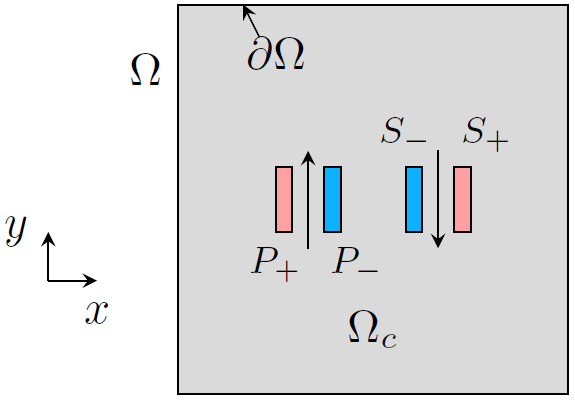

In [ ]:
###############################################################################
## CODE CELL 1 : Import transformer mesh
###############################################################################

from utils.geometry import transformer
from ngsolve.webgui import Draw

mesh = transformer(maxh = 0.1)                   #  mesh the transformer geometry
print(f"Region names : {mesh.GetMaterials()}")   # display the regions (materials) labels
print(f"Line names : {mesh.GetBoundaries()}")    # display the lines (boundaries) labels
Draw(mesh)

### ii) Density

To define the core geometry, we introduce a so-called **density field** $\rho:\Omega_c \rightarrow [0,1]$ which is the **optimization variable**, so that:
- $\rho=0$ is associated with **<u>air</u>** with a magnetic reluctivity $\nu_{air} = 1/\mu_{air}$, and $\mu_{air} = \mu_0 = 4\times 10^{-7} H/m$
- $\rho=1$ is associated with **<u>iron</u>** with a magnetic reluctivity $\nu_{iron} = 1/(\mu_r\mu_{air})$ and $\mu_r=1000$
- **intermediate magnetic properties** are **<u>interpolated</u>** on intermediate $\rho$ values 

There is some freedom on the choice of $\nu$ interpolation. An usual choice is to use a power law, also called "SIMP" interpolation:

$$ \nu(\rho) = \nu_{air} + \rho^p (\nu_{iron} - \nu_{air}),$$

with $p\geq 1$. It is not the only possibility, for instance we can also interpolate the magnetic permeability $\mu=1/\nu$:
$$ \mu(\rho) = \mu_{air} + \rho^p (\mu_{iron} - \mu_{air}),$$

which gives the following $\nu$-interpolation
$$\nu(\rho) = \frac{1}{\frac{1}{\nu_{air}} + \rho^p (\frac{1}{\nu_{iron}} - \frac{1}{\nu_{air}}) }.$$

Many other choices are possible, see for instance [10.1016/j.jmmm.2025.173646](https://doi.org/10.1016/j.jmmm.2025.173646), [10.1108/COMPEL-04-2017-0170](https://doi.org/10.1108/COMPEL-04-2017-0170).

For now, we chose $p=1$, we'll see its influence later.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 2 : Define interpolation of the magnetic reluctivity
###############################################################################

from numpy import pi
mu0 = 4e-7 * pi   # magnetic permeability of air (H/m)
mur = 1000        # relative magnetic permeability of the iron    
p = 1

def nu(rho, p=1):
    """ reluctivity depending on the density """
    return 1/mu0 + rho**p * (1/(mu0*mur) - 1/mu0)  # power law interpolation of nu
    # return 1/ (mu0 + rho**p * (mur*mu0 -mu0))    # power law interpolation of mu

# Plot the interpolation
import matplotlib.pyplot as plt
import numpy as np

rho = np.linspace(0,1,100)
plt.plot(rho, nu(rho,p)); plt.xlabel("$\\rho$"); 
plt.ylabel("$\\nu(\\rho)$"); plt.grid(); 
plt.title("Interpolation of the magnetic reluctivity")
plt.show()

### iii) Magnetic state

The magnetic state depends on the density field $\rho$ implicitely by solving the state equation

$$
\text{find $a_\rho \in H^1_0(\Omega)$, such that }
$$
$$
\forall v \in H^1_0(\Omega), \quad  \mathcal R(a_\rho, v, \rho) = \int_\Omega \text{curl}\;v \cdot \nu(\rho) \text{curl}\;a_\rho - \int_{P_+} v j + \int_{P_-} v j = 0,
$$

with $j = 10^6 A/m²$, and $\mathcal R(a, v)$ the residual. To highligh the implicit dependance in $\rho$, we write $a_\rho$, while when a magnetic state is decorrelated from $\rho$ we write $a$. 

Look at [this notebook](1_FEM_forward_problem.ipynb) to see how to implement the abovementioned magnetostatic weak formulation, and this [cheat sheet](B_NGSolve_cheat_sheet.ipynb) for a reminder of NGSolve syntax.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 3 : Define the magnetostatic solver
###############################################################################

j = 1e6 # current density in the primary coil (A/m²)

from ngsolve import CF, grad

def curl(v):
    R = CF(((0,1),(-1,0)), dims = (2,2))  # Rotation matrix of angle -pi/2
    return R * grad(v)

from ngsolve import H1, BilinearForm, LinearForm, dx
from utils.solver import solve

def state(rho):
    """ Solve the state equation for a given density field rho """
    fes = H1(mesh, order = 1, dirichlet = "dOmega")
    a, v = fes.TnT()    # define the trial and test functions 
    bf = BilinearForm(curl(v) * (nu(rho) * curl(a)) * dx)  
    lf = LinearForm(j * v * dx("Pp") - j * v * dx("Pm"))
    return solve(bf, lf)

# Test your function
a_rho, Kinv = state(0)
Draw(a_rho)

### iv) Objective function

We want to maximize the magnetic flux, which is
$$\phi(a) = L_z N_s \left(\frac{1}{|S^+|} \int_{S^+} a - \frac{1}{|S^-|}\int_{S^-} a \right)$$
with $N_s$ the number of turns of the secondary winding, and $L_z$ the length of the transformer in the $z$ direction (normalized to $L_z = 1m$ here). To comply with optimization customs and traditions, we define 
$$f(\rho) := -\phi(a_\rho)$$
the objective function to **<u>minimize</u>**.

|**<font color='red'>[FILL & RUN]</font>**|
|---|


In [ ]:
###############################################################################
## CODE CELL 4 : Compute the flux
###############################################################################

from ngsolve import Integrate

Ns = 100   # turns
Lz = 1     # z-length (normalized to 1m)

Sp = Integrate(1, mesh, definedon = mesh.Materials("Sp"))
Sm = Integrate(1, mesh, definedon = mesh.Materials("Sm"))

def flux(sol):
    """ Compute the flux in the secondary coil """
    aSp = Integrate(sol, mesh, definedon = mesh.Materials("Sp"))
    aSm = Integrate(sol, mesh, definedon = mesh.Materials("Sm"))
    return Ns * Lz * (aSp/Sp - aSm/Sm)

def f(rho, sol = None):
    """ Objective function to minimize """
    if sol is None:     # compute the state if not given
        sol, _ = state(rho)
    return -flux(sol)

# Test your function
print(f"Secondary flux =  {flux(a_rho):.3e} Wb/m")
print(f"Objective      = {f(0):.3e} Wb/m")

### v) Optimization problem

We are now able to state the optimization problem mathematically:

$$\text{find}\; \rho^* = \arg \min_{\rho:\Omega_c\rightarrow [0,1]} - L_z N_s \left(\frac{1}{|S^+|} \int_{S^+} a_\rho - \frac{1}{|S^-|}\int_{S^-} a_\rho \right)$$

with 
$$\forall v \in H^1_0(\Omega), \quad \int_\Omega \text{curl}\;v \cdot \nu(\rho) \text{curl}\;a_\rho - \int_{P_+} v j + \int_{P_-} v j = 0$$

We can solve this problem numerically with a **<u>gradient descent</u>**.

___
## B) Optimization loop

### i) Derivative computation
To apply our optimization algorithm, we need a  $\delta \rho$ that is a **descent direction** for the objective $f$. Such a descent direction should satisfy 
$$ f'(\rho; \delta) < 0 $$
and can be obtain by studying the directional derivative of the objective $f'$.

#### Formal Lagrangian approach

Let us define a Lagrangian that depends on independant variables
$$ \mathcal L(a, v, \rho) =  -\phi(a) + \mathcal R(a,v,\rho)$$
$$\Rightarrow \mathcal L(a, v, \rho) =  - L_z N_s \left(\frac{1}{|S^+|} \int_{S^+} a - \frac{1}{|S^-|}\int_{S^-} a \right) + \int_\Omega \text{curl}\;v \cdot \nu(\rho) \text{curl}\;a - \int_{P_+} v j_z + \int_{P_-} v j_z$$

When $a = a_\rho$, then $R(a_\rho,v,\rho) = 0 $ and we have
$$\mathcal L(a_\rho, v, \rho) =  -\phi(a_\rho) = f(\rho)$$
so
$$ f'(\rho) = d_\rho \mathcal L(a_\rho, v, \rho)$$
whatever $v\in H^1_0(\Omega)$, which is an additional degree of freedom we can use to simplify the computation of $f'(\rho).$

#### Chain rule
Since $v$ and $\rho$ are independant, but not $a_\rho$ and $\rho$, the chain rule gives
$$ f'(\rho; \delta \rho) = \partial_\rho \mathcal L(a_\rho, v, \rho; \delta \rho) + \partial_a \mathcal L(a_\rho, v, \rho; \textcolor{red}{d_\rho a_\rho(\delta \rho)}) $$

with the red term $\textcolor{red}{d_\rho a_\rho(\delta \rho)}$ being difficult to compute due to the implicit relation between $a_\rho$ and $\rho$.

#### Adjoint
The trick is to find a special value of $v$ that we note $\textcolor{green}{v_\rho}$ and called the "**<u>adjoint state</u>**" such that 

$$\forall \textcolor{red}{a} \in H^1_0(\Omega), \quad \partial_a \mathcal L(a_\rho, \textcolor{green}{v_\rho}, \rho; \textcolor{red}{a}) = -\phi'(a_\rho; \textcolor{red}{a}) + \partial_a \mathcal R(a_\rho, v_\rho, \rho; \textcolor{red}{a})= 0$$

$$\Rightarrow \forall \textcolor{red}{a} \in H^1_0(\Omega), \quad \int_\Omega \text{curl}\;\textcolor{green}{v_\rho} \cdot \nu(\rho) \text{curl}\; \textcolor{red}{a} = L_z N_s \left(\frac{1}{|S^+|} \int_{S^+} \textcolor{red}{a} - \frac{1}{|S^-|}\int_{S^-} \textcolor{red}{a} \right)$$

so we don't have to compute the problematic term $\textcolor{red}{d_\rho a_\rho(\delta \rho)}$, and then

$$ f'(\rho; \delta \rho) = \partial_\rho \mathcal L(a_\rho, \textcolor{green}{v_\rho}, \rho; \delta \rho) $$

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 5 : Adjoint state
###############################################################################

def adjoint(rho):
    """ Solve the adjoint equation for a given magnetic state """
    fes = H1(mesh, order = 1, dirichlet = "dOmega")
    v_rho, a = fes.TnT()    # define the trial and test functions 
    bf = BilinearForm(curl(v_rho) * (nu(rho) * curl(a)) * dx)  
    lf = LinearForm(Ns * Lz * (a/Sp * dx("Sp") - a/Sm * dx("Sm")))
    return solve(bf, lf)[0]


# Test your function
v_rho = adjoint(0)
Draw(v_rho)

We note that the bilinear form used in the adjoint equation is actually the **adjoint** of the bilinear form of the state equations, i.e.:
$$b^*(u,v) = b(v,u),$$
So that the computation of the adjoint can be optimized by taking the (conjugate) **transpose** of the already decomposed matrix. So, we can encapsulate everything in the `solve_adjoint` function.

In [ ]:
###############################################################################
## CODE CELL 5 : Efficient adjoint state
###############################################################################

from utils.optimization import solve_adjoint

def df(state, rho, a):
    """ directional derivative of the objective function """
    return - Ns * Lz * (a/Sp * dx("Sp") - a/Sm * dx("Sm"))

# Test your function
v_rho = solve_adjoint(a_rho, rho, Kinv, df)
Draw(v_rho)